In [1]:
import pickle, copy, json
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['text.usetex'] = False
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import matplotlib as mpl
import matplotlib.cm as cm
import scipy.stats as sps
from random import shuffle
import itertools

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
#import la_forge.utils as lf_utils
#lf_utils.set_publication_params({'text.usetex':False})
#fig_dir = '/home/baierj/projects/hasasia2/hasasia2_paper/figures'

In [2]:
import healpy as hp
import astropy.units as u
import astropy.constants as c
from astropy.coordinates import SkyCoord
#import plot #Script originally written by Leo Stein for making pretty sky maps. 

# Setting various healpy quantities and GW source sky positions.
NSIDE = 8
NPIX = hp.nside2npix(NSIDE)
IPIX = np.arange(NPIX)
theta_gw, phi_gw = hp.pix2ang(nside=NSIDE,ipix=IPIX)

In [12]:
import numpy as np
import scipy.linalg as sl
import matplotlib.pyplot as plt
%matplotlib inline
import glob, pickle, json
import hasasia.sensitivity as hsen
import hasasia.sim as hsim
import hasasia.skymap as hsky
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300
mpl.rcParams['figure.figsize'] = [5,3]
mpl.rcParams['text.usetex'] = True
from enterprise.pulsar import Pulsar as ePulsar


In [18]:
#get v1p1
ng20_irn = '/Users/ashokan/osu/sarahspta/data/NG20v1p1_irn_with_EF_EQ_factor/'
pardir = ng20_irn
timdir = ng20_irn
pars = sorted(glob.glob(pardir+'*.par'))
tims = sorted(glob.glob(timdir+'*.tim'))

In [19]:
#check number of pulsars
print(len(pars))
print(len(tims))

80
80


In [20]:
#check first par and tim files
print(pars[0])
print(tims[0])

/Users/ashokan/osu/sarahspta/data/NG20v1p1_irn_with_EF_EQ_factor/B1855+09.par
/Users/ashokan/osu/sarahspta/data/NG20v1p1_irn_with_EF_EQ_factor/B1855+09.tim


In [21]:
#make enterprise pulsars
ePsrs = []
for par,tim in zip(pars,tims):
    # if 'J1802' in par:
    #     continue #this pulsar has some issue
    #else:
    ePsr = ePulsar(par, tim,  ephem='DE440')
    ePsrs.append(ePsr)
    print('\rPSR {0} complete'.format(ePsr.name),end='',flush=True)

2025-10-10 20:13:25.381 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 20:13:25.505 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 20:13:25.508 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 20:13:25.517 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:13:25.518 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 20:13:25.519 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 20:13:25.578 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:13:25.579 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR B1855+09 complete

2025-10-10 20:13:26.717 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 20:13:26.937 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 20:13:26.942 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 20:13:26.953 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:13:26.954 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 20:13:26.954 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 20:13:27.016 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:13:27.017 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR B1937+21 complete

2025-10-10 20:13:28.202 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 20:13:28.323 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 20:13:28.326 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 20:13:28.336 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:13:28.338 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 20:13:28.338 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 20:13:28.405 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:13:28.407 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

...

PSR J2302+4442 complete

2025-10-10 20:14:58.276 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 20:14:58.454 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 20:14:58.457 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 20:14:58.476 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:14:58.477 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 20:14:58.479 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 20:14:58.584 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:14:58.584 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR J2317+1439 complete

2025-10-10 20:14:59.853 | DEBUG    | pint.toa:get_TOAs:211 - Using CLOCK = BIPM2023 from the given model
2025-10-10 20:15:00.119 | DEBUG    | pint.toa:__init__:1377 - No pulse number flags found in the TOAs
2025-10-10 20:15:00.120 | DEBUG    | pint.toa:apply_clock_corrections:2232 - Applying clock corrections (include_bipm = True)
2025-10-10 20:15:00.124 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:15:00.125 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock correction (~27 us)
2025-10-10 20:15:00.126 | INFO     | pint.observatory.topo_obs:clock_corrections:340 - Applying observatory clock corrections for observatory='arecibo'.
2025-10-10 20:15:00.168 | INFO     | pint.observatory:gps_correction:230 - Applying GPS to UTC clock correction (~few nanoseconds)
2025-10-10 20:15:00.169 | INFO     | pint.observatory:bipm_correction:245 - Applying TT(TAI) to TT(BIPM2023) clock co

PSR J2322+2057 complete

In [22]:
#make a noise dict that  works 

#sarah's noise file
sarahs_noise_file = '/Users/ashokan/osu/sarahspta/20yr_noisedict_rn+curn-bpl.json'
import json
with open(sarahs_noise_file,'r') as f:
    noise = json.load(f)
rn_psrs = noise
#print(rn_psrs)

#Nihan's noise dict for 15yr 
nihans_dict = '/Users/ashokan/osu/sarahspta/15yr_v1_fl_fwn_dict.json'
with open(nihans_dict,'r') as f:
    nihans_noise = json.load(f)

#NG20 real noise dict
ng20_noise_dict = '/Users/ashokan/osu/sarahspta/ng20_v1p1_dmx_noise_dict.json'
#from https://drive.google.com/drive/folders/1GQXnpyRglqPHwgQs6vE8VK-6VoL9WbSj
with open(ng20_noise_dict,'r') as f:
    ng20_noise_real = json.load(f)

#make a new noise dict with only chime and vegas pulsars
chime_vegas_noise_dict = {}
for k, v in ng20_noise_real.items():
    new_key = k.replace("t2equad", "equad")
    if "CHIME" in k or "YUPPI" in k or "VEGAS" in k or "J0125-2327" in k or "J0154+1833" in k or "J0614-3329" in k or "J0621+2514" in k or "J0732+2314" in k or "J0751+1807" in k or "J1022+1001" in k or "J1803+1358" in k or "J2022+2534" in k or "J2039-3616" in k or "J2150-0326" in k:
        print(k)
        chime_vegas_noise_dict[new_key] = v

#update nihans noise dict with chime and vegas pulsars from ng20
nihans_noise.update(chime_vegas_noise_dict)

B1855+09_CHIME_efac
B1855+09_CHIME_log10_ecorr
B1855+09_CHIME_log10_t2equad
B1855+09_Rcvr1_2_VEGAS_efac
B1855+09_Rcvr1_2_VEGAS_log10_ecorr
B1855+09_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_3GHz_YUPPI_efac
B1937+21_3GHz_YUPPI_log10_ecorr
B1937+21_3GHz_YUPPI_log10_t2equad
B1937+21_CHIME_efac
B1937+21_CHIME_log10_ecorr
B1937+21_CHIME_log10_t2equad
B1937+21_Rcvr1_2_VEGAS_efac
B1937+21_Rcvr1_2_VEGAS_log10_ecorr
B1937+21_Rcvr1_2_VEGAS_log10_t2equad
B1937+21_Rcvr_800_VEGAS_efac
B1937+21_Rcvr_800_VEGAS_log10_ecorr
B1937+21_Rcvr_800_VEGAS_log10_t2equad
B1953+29_CHIME_efac
B1953+29_CHIME_log10_ecorr
B1953+29_CHIME_log10_t2equad
J0023+0923_CHIME_efac
J0023+0923_CHIME_log10_ecorr
J0023+0923_CHIME_log10_t2equad
J0023+0923_Rcvr1_2_VEGAS_efac
J0023+0923_Rcvr1_2_VEGAS_log10_ecorr
J0023+0923_Rcvr1_2_VEGAS_log10_t2equad
J0030+0451_CHIME_efac
J0030+0451_CHIME_log10_ecorr
J0030+0451_CHIME_log10_t2equad
J0030+0451_Rcvr1_2_VEGAS_efac
J0030+0451_Rcvr1_2_VEGAS_log10_ecorr
J0030+0451_Rcvr1_2_VEGAS_log10_t2equad
J0

In [23]:
def make_corr(psr,noise):
    N = psr.toaerrs.size
    corr = np.zeros((N,N))
    _, _, fl, _, bi = hsen.quantize_fast(psr.toas,psr.toaerrs,
                                         flags=psr.flags['f'],dt=1)
    keys = [ky for ky in noise.keys() if psr.name in ky]
    backends = np.unique(psr.flags['f'])
    sigma_sqr = np.zeros(N)
    ecorrs = np.zeros_like(fl,dtype=float)
    for be in backends:
        mask = np.where(psr.flags['f']==be)
        key_ef = '{0}_{1}_{2}'.format(psr.name,be,'efac')
        key_eq = '{0}_{1}_log10_{2}'.format(psr.name,be,'equad')
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        sigma_sqr[mask] = (noise[key_ef]**2 * ((psr.toaerrs[mask]**2)
                           + (10**noise[key_eq])**2))#+(10**noise[key_ec])**2)
        mask_ec = np.where(fl==be)
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        ecorrs[mask_ec] = np.ones_like(mask_ec) * (10**noise[key_ec])
    j = [ecorrs[ii]**2*np.ones((len(bucket),len(bucket)))
         for ii, bucket in enumerate(bi)]

    J = sl.block_diag(*j)
    corr = np.diag(sigma_sqr) + J
    return corr

In [24]:
#make correlation matrix with only toaerrs for Sarah's data
def make_corr_our(psr):
    sigma_sqrt = psr.toaerrs**2
    corr = np.diag(sigma_sqrt)
    return corr


In [25]:
Tspan = hsen.get_Tspan(ePsrs)
fyr = 1/(365.25*24*3600)
freqs = np.logspace(np.log10(1/(5*Tspan)),np.log10(2e-7),600)

In [26]:
#make hasasia pulsars from enterprise pulsars.
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
for ePsr in ePsrs:
    corr = make_corr_our(ePsr)[::thin,::thin]
    nihans_corr = make_corr(ePsr,nihans_noise)
    plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
    if ePsr.name in rn_psrs.keys():
        Amp, gam = rn_psrs[ePsr.name]
        plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

    nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                               toas=ePsr.toas[::thin])
    psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                      toaerrs=ePsr.toaerrs[::thin],
                      phi=ePsr.phi,theta=ePsr.theta,
                      N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
    psr.name = ePsr.name
    psrs.append(psr)
    del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

PSR J2322+2057 complete

In [27]:
#make spectra
specs = []
for p in psrs:
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    print('\rPSR {0} complete'.format(p.name),end='',flush=True)
ng20_sarah_nihans_wn = hsen.GWBSensitivityCurve(specs)

PSR J2322+2057 complete

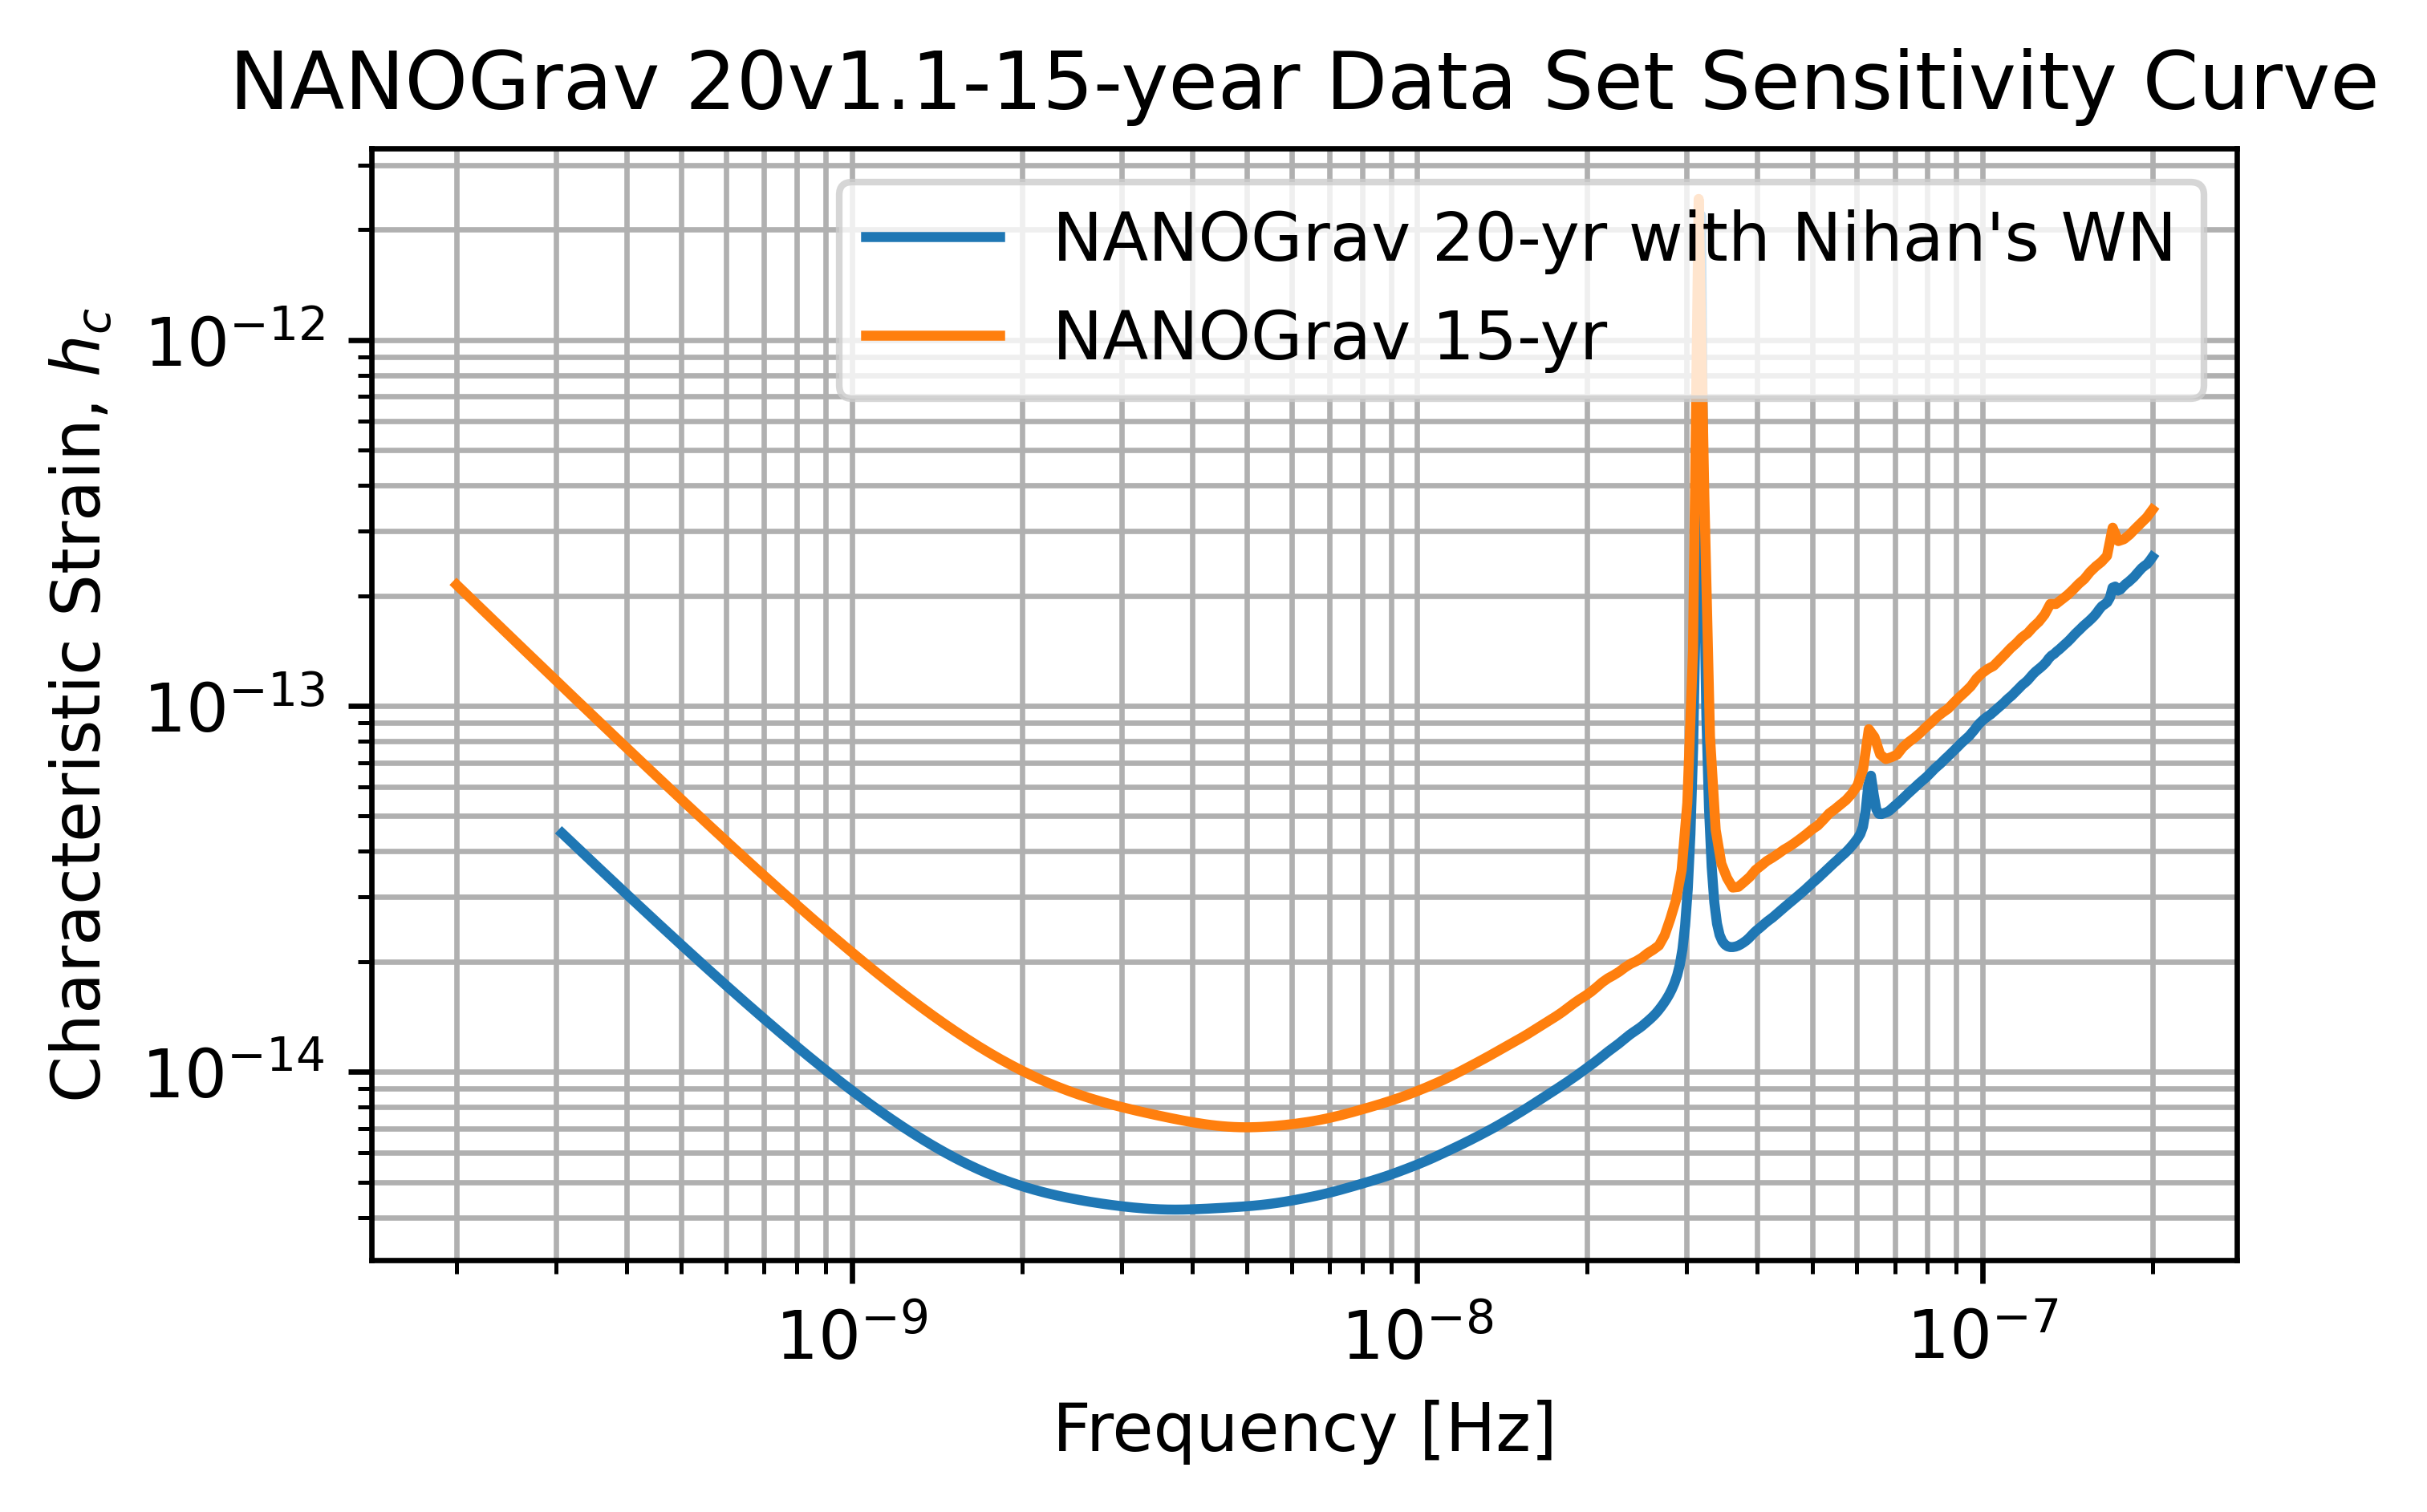

In [29]:
#plot against original NG15 curve
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = False
ng15_pkl_gwb = '/Users/ashokan/osu/sarahspta/ng15yr_v1p1_pint_logf_m2a_red_noise_vg_gwbsc.has' 
with open (ng15_pkl_gwb,'rb') as f:
    ng15_sc_gwb = pickle.load(f)

plt.loglog(ng20_sarah_nihans_wn.freqs,ng20_sarah_nihans_wn.h_c,label='NANOGrav 20-yr with Nihan\'s WN')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title('NANOGrav 20v1.1-15-year Data Set Sensitivity Curve')
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()

In [30]:
#SNR of full NG20 data now
alpha_gwb = (3. - gamma_gwb) / 2.
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
snr_20 = ng20_sarah_nihans_wn.SNR(S_h)
print(snr_20)

10.207047213274071


Okay that is how the full NG20 dataset from Sarah looks like in comparison to NG15. Now lets slice it to 15 year.

In [31]:
def get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects
        
    cutoff : float
        MJD cutoff for the calculation
    
    sigma_correction : ?
        ???
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
            #idxs.append(idx)
           pass
        else:
            psrs_cut.append(psr)
    timespan = hsen.get_Tspan(psrs_cut)
    spectra = []
    for idx, p in enumerate(psrs_cut):
        sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
        sp.name = p.name
        _ = sp.NcalInv
        #print(f"psr spectra {idx} is done")
        spectra.append(sp)
    print(f"PTA spectrum with {len(spectra)} psrs created.")
    return spectra

In [32]:
end_mjd = 59033
psr_spectra = get_sliced_spectra(psrs, 
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

PTA spectrum with 67 psrs created.


In [33]:
#SNR of sliced data
A_gwb, gamma_gwb = 6.4e-15, 3.2
sliced_GWBSC = hsen.GWBSensitivityCurve(spectra=psr_spectra, orf='hd', autocorr=False)
S_h = hsen.S_h(A=A_gwb, alpha=alpha_gwb, freqs=freqs)
sliced_SNR = sliced_GWBSC.SNR(S_h)
print(sliced_SNR)

6.5192278478159045


In [34]:
print(len(psrs))
print(len(psr_spectra)) #If there are no TOAs remaining or < 3 years of data pulsar gets left out

80
67


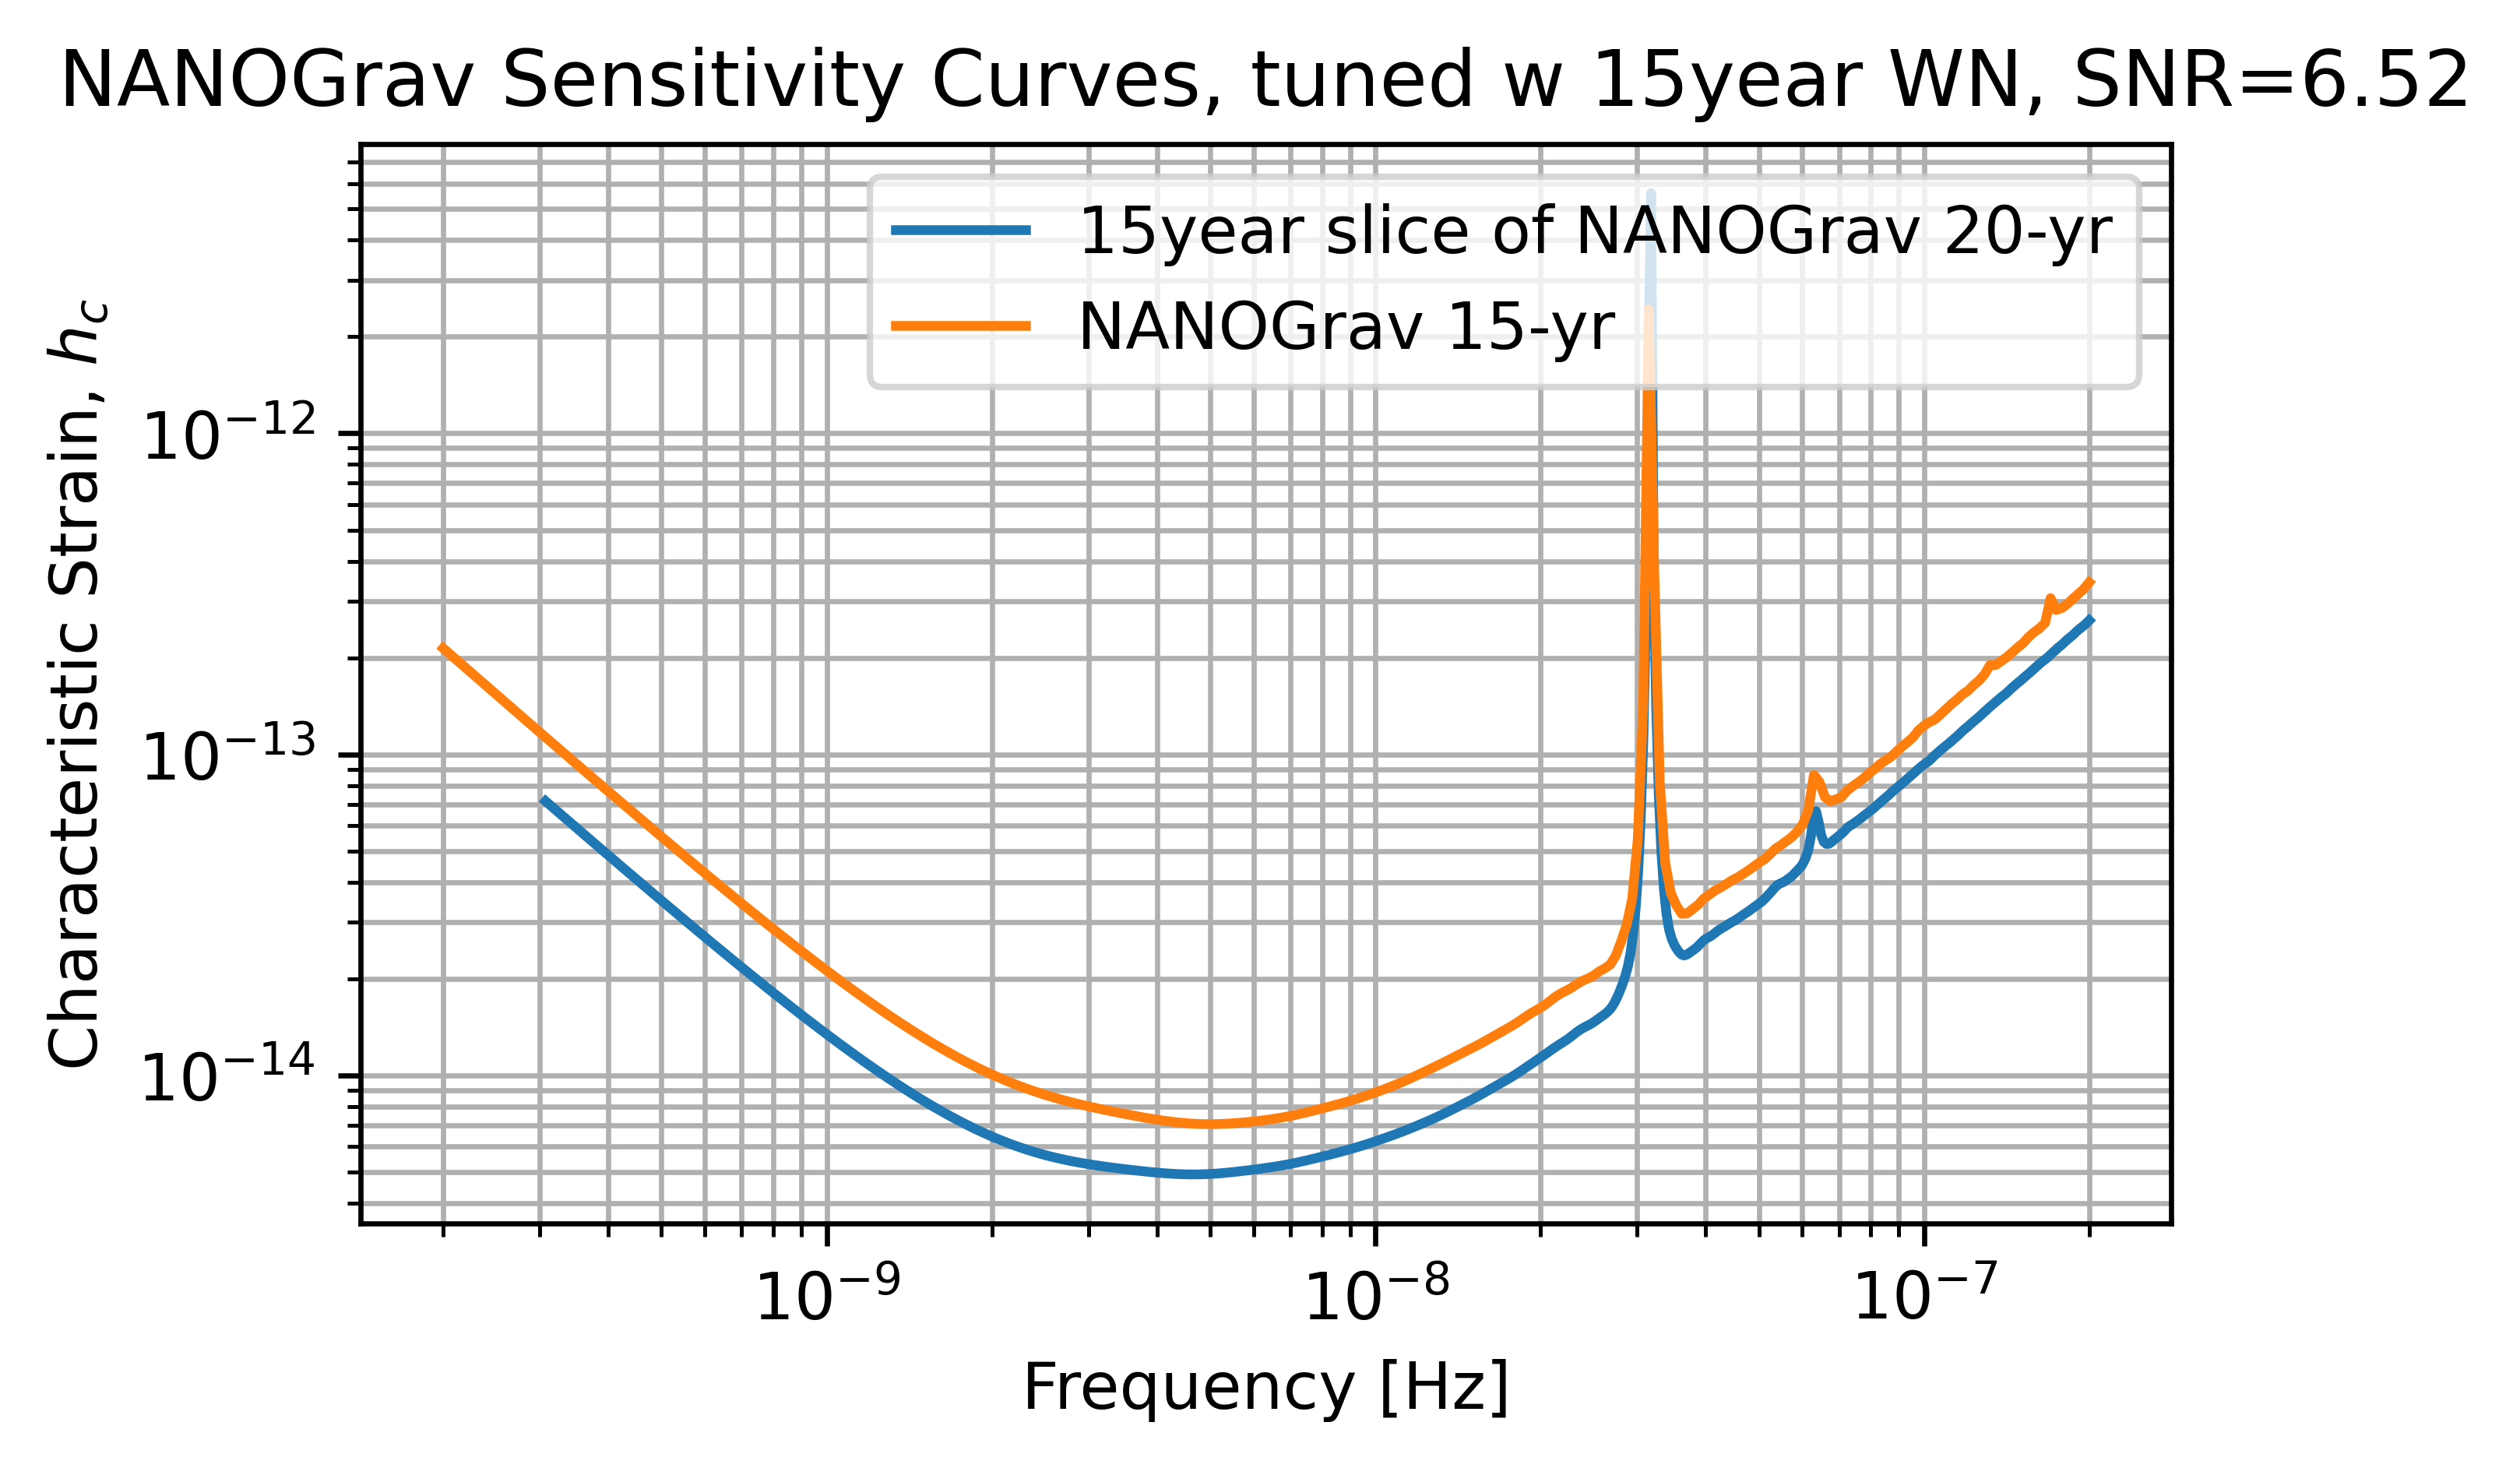

In [35]:
#plot 15year slice of NG20 against NG15
plt.loglog(sliced_GWBSC.freqs,sliced_GWBSC.h_c,label='15year slice of NANOGrav 20-yr')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title(
'NANOGrav Sensitivity Curves, tuned w 15year WN, SNR={:.2f}'.format(
    sliced_SNR
)
)

#plt.title('NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}'.format(FACTOR),'SNR={:.2f}'.format(sliced_with_factor_SNR))

plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()

Okay this has an SNR of 6.5
We want it to be 5 as was in the original NG15 analysis.

Lets tune its white noise. 

We'll have to use enterprise pulsar objects and chop because hasasia pulsars have no flags etc and their ecorr equad etc become a pain to use in the expression for sigma^2

In [43]:
#We tune by multiplying toaerrs by a FACTOR
def make_corr_our_tuning_with_all_wn(psr,noise,FACTOR=1.0):
    N = psr.toaerrs.size
    corr = np.zeros((N,N))
    _, _, fl, _, bi = hsen.quantize_fast(psr.toas,psr.toaerrs,
                                         flags=psr.flags['f'],dt=1)
    keys = [ky for ky in noise.keys() if psr.name in ky]
    backends = np.unique(psr.flags['f'])
    sigma_sqr = np.zeros(N)
    ecorrs = np.zeros_like(fl,dtype=float)
    for be in backends:
        mask = np.where(psr.flags['f']==be)
        key_ef = '{0}_{1}_{2}'.format(psr.name,be,'efac')
        key_eq = '{0}_{1}_log10_{2}'.format(psr.name,be,'equad')
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        sigma_sqr[mask] = (noise[key_ef]**2 * (FACTOR*(psr.toaerrs[mask]**2)
                           + (10**noise[key_eq])**2))#+(10**noise[key_ec])**2)
        mask_ec = np.where(fl==be)
        key_ec = '{0}_{1}_log10_{2}'.format(psr.name,be,'ecorr')
        ecorrs[mask_ec] = np.ones_like(mask_ec) * (10**noise[key_ec])
    j = [ecorrs[ii]**2*np.ones((len(bucket),len(bucket)))
         for ii, bucket in enumerate(bi)]

    J = sl.block_diag(*j)
    corr = np.diag(sigma_sqr) + J
    return corr

Lets try to chop enterprise pulsars instead of hasasia pulsars.

In [39]:
def get_sliced_epulsars(psrs, 
                       start_mjd=1,
                       end_mjd = None,
                       ):
    """
    Parameters 
    ----------
    
    psrs : list of enterprise.Pulsar or list of hasasia.Pulsar objects
        List of enterprise/hasasia Pulsar objects

    start_mjd : float
        MJD start time for the calculation

    end_mjd : float
        MJD end time for the calculation
    """
    psrs_cut = []
    psrs_copy = copy.deepcopy(psrs)
    for idx, psr in enumerate(psrs_copy):
        # filter the data around to the appropriate slice
        #print("N_toa = ", len(psr.toas))
        psr.filter_data(start_time=start_mjd, end_time=end_mjd)
        #print("after filter = ", len(psr.toas)) 
        # If there are no TOAs remaining, or the time span of the pulsar is <3 cut.
        if (psr.toas.size == 0) or (hsen.get_Tspan([psr]) < 3*365.25*24*3600):
    #         idxs.append(idx)
            pass
        else:
            psrs_cut.append(psr)
    return psrs_cut

In [40]:
end_mjd = 59033
epsrs_cut_NG15 = get_sliced_epulsars(ePsrs, 
                       start_mjd=1,
                       end_mjd = end_mjd,
                       )

In [41]:
print(len(ePsrs))
print(len(epsrs_cut_NG15)) #once again if no TOAs or < 3 years of data pulsar gets left out

80
67


## Loop over prefactors

FACTOR =  2.518656922136738
PSR J2322+2057 completesliced_with_factor_SNR =  5.008697545082477


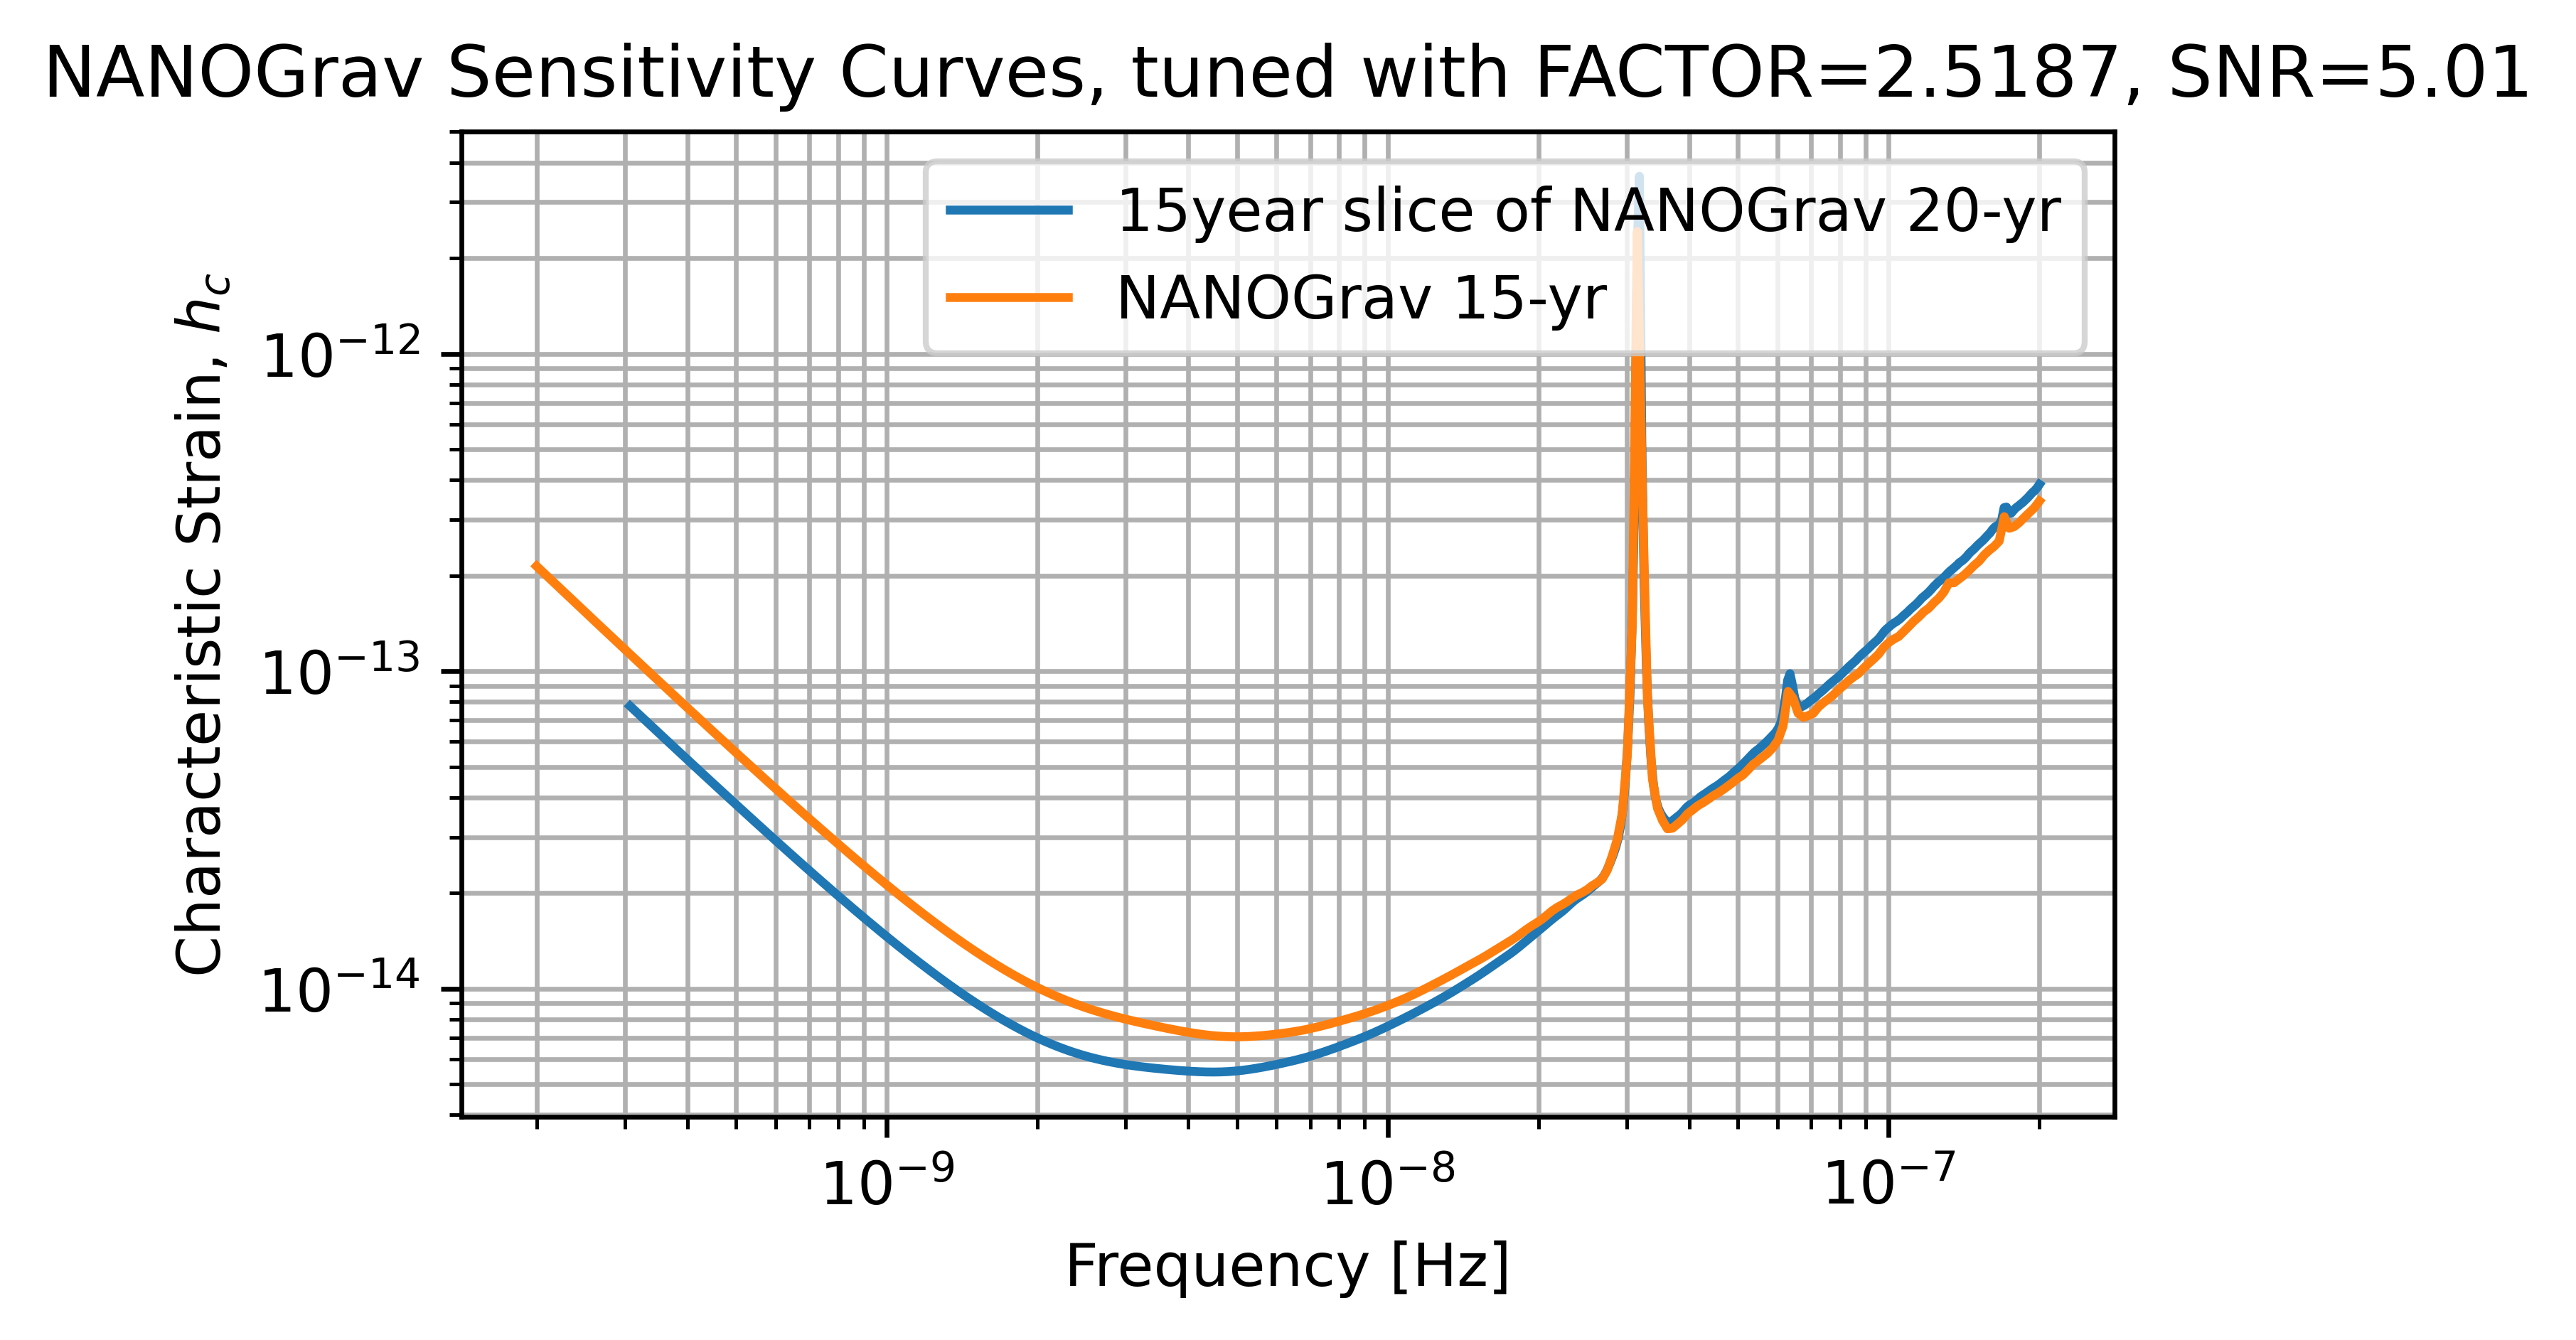

FACTOR =  2.531507212555803
PSR J2322+2057 completesliced_with_factor_SNR =  5.00128612258093


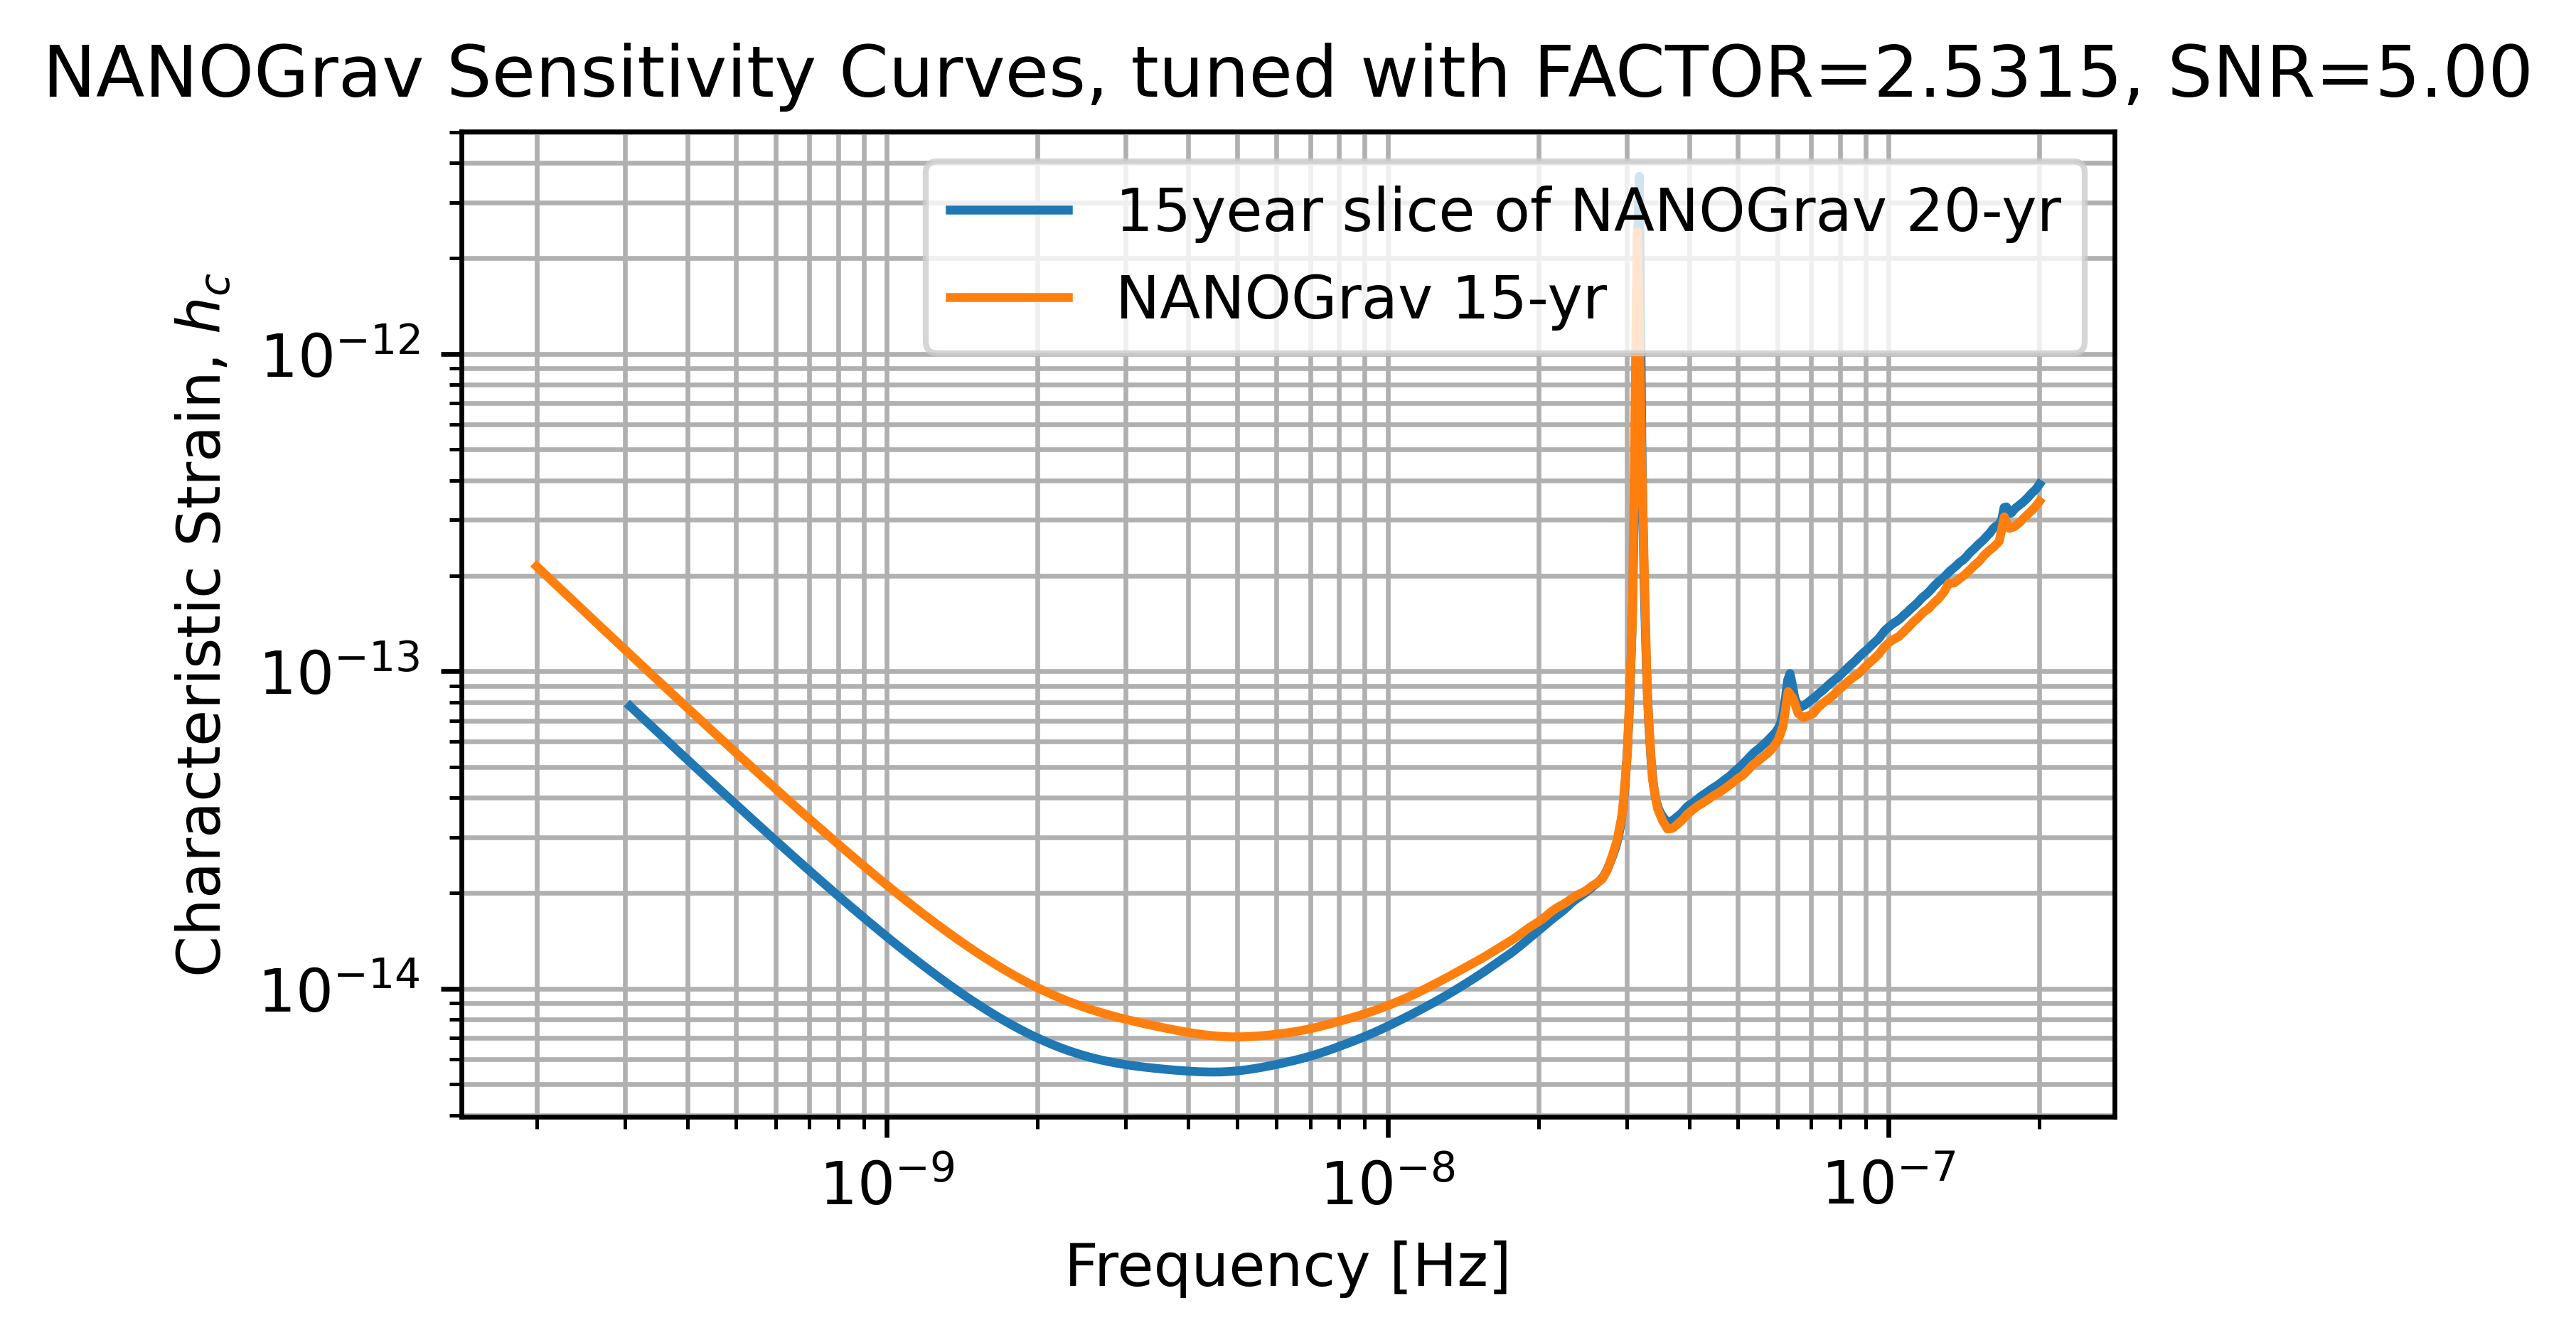

FACTOR =  2.544357502974868
PSR J2322+2057 completesliced_with_factor_SNR =  4.99391353770245


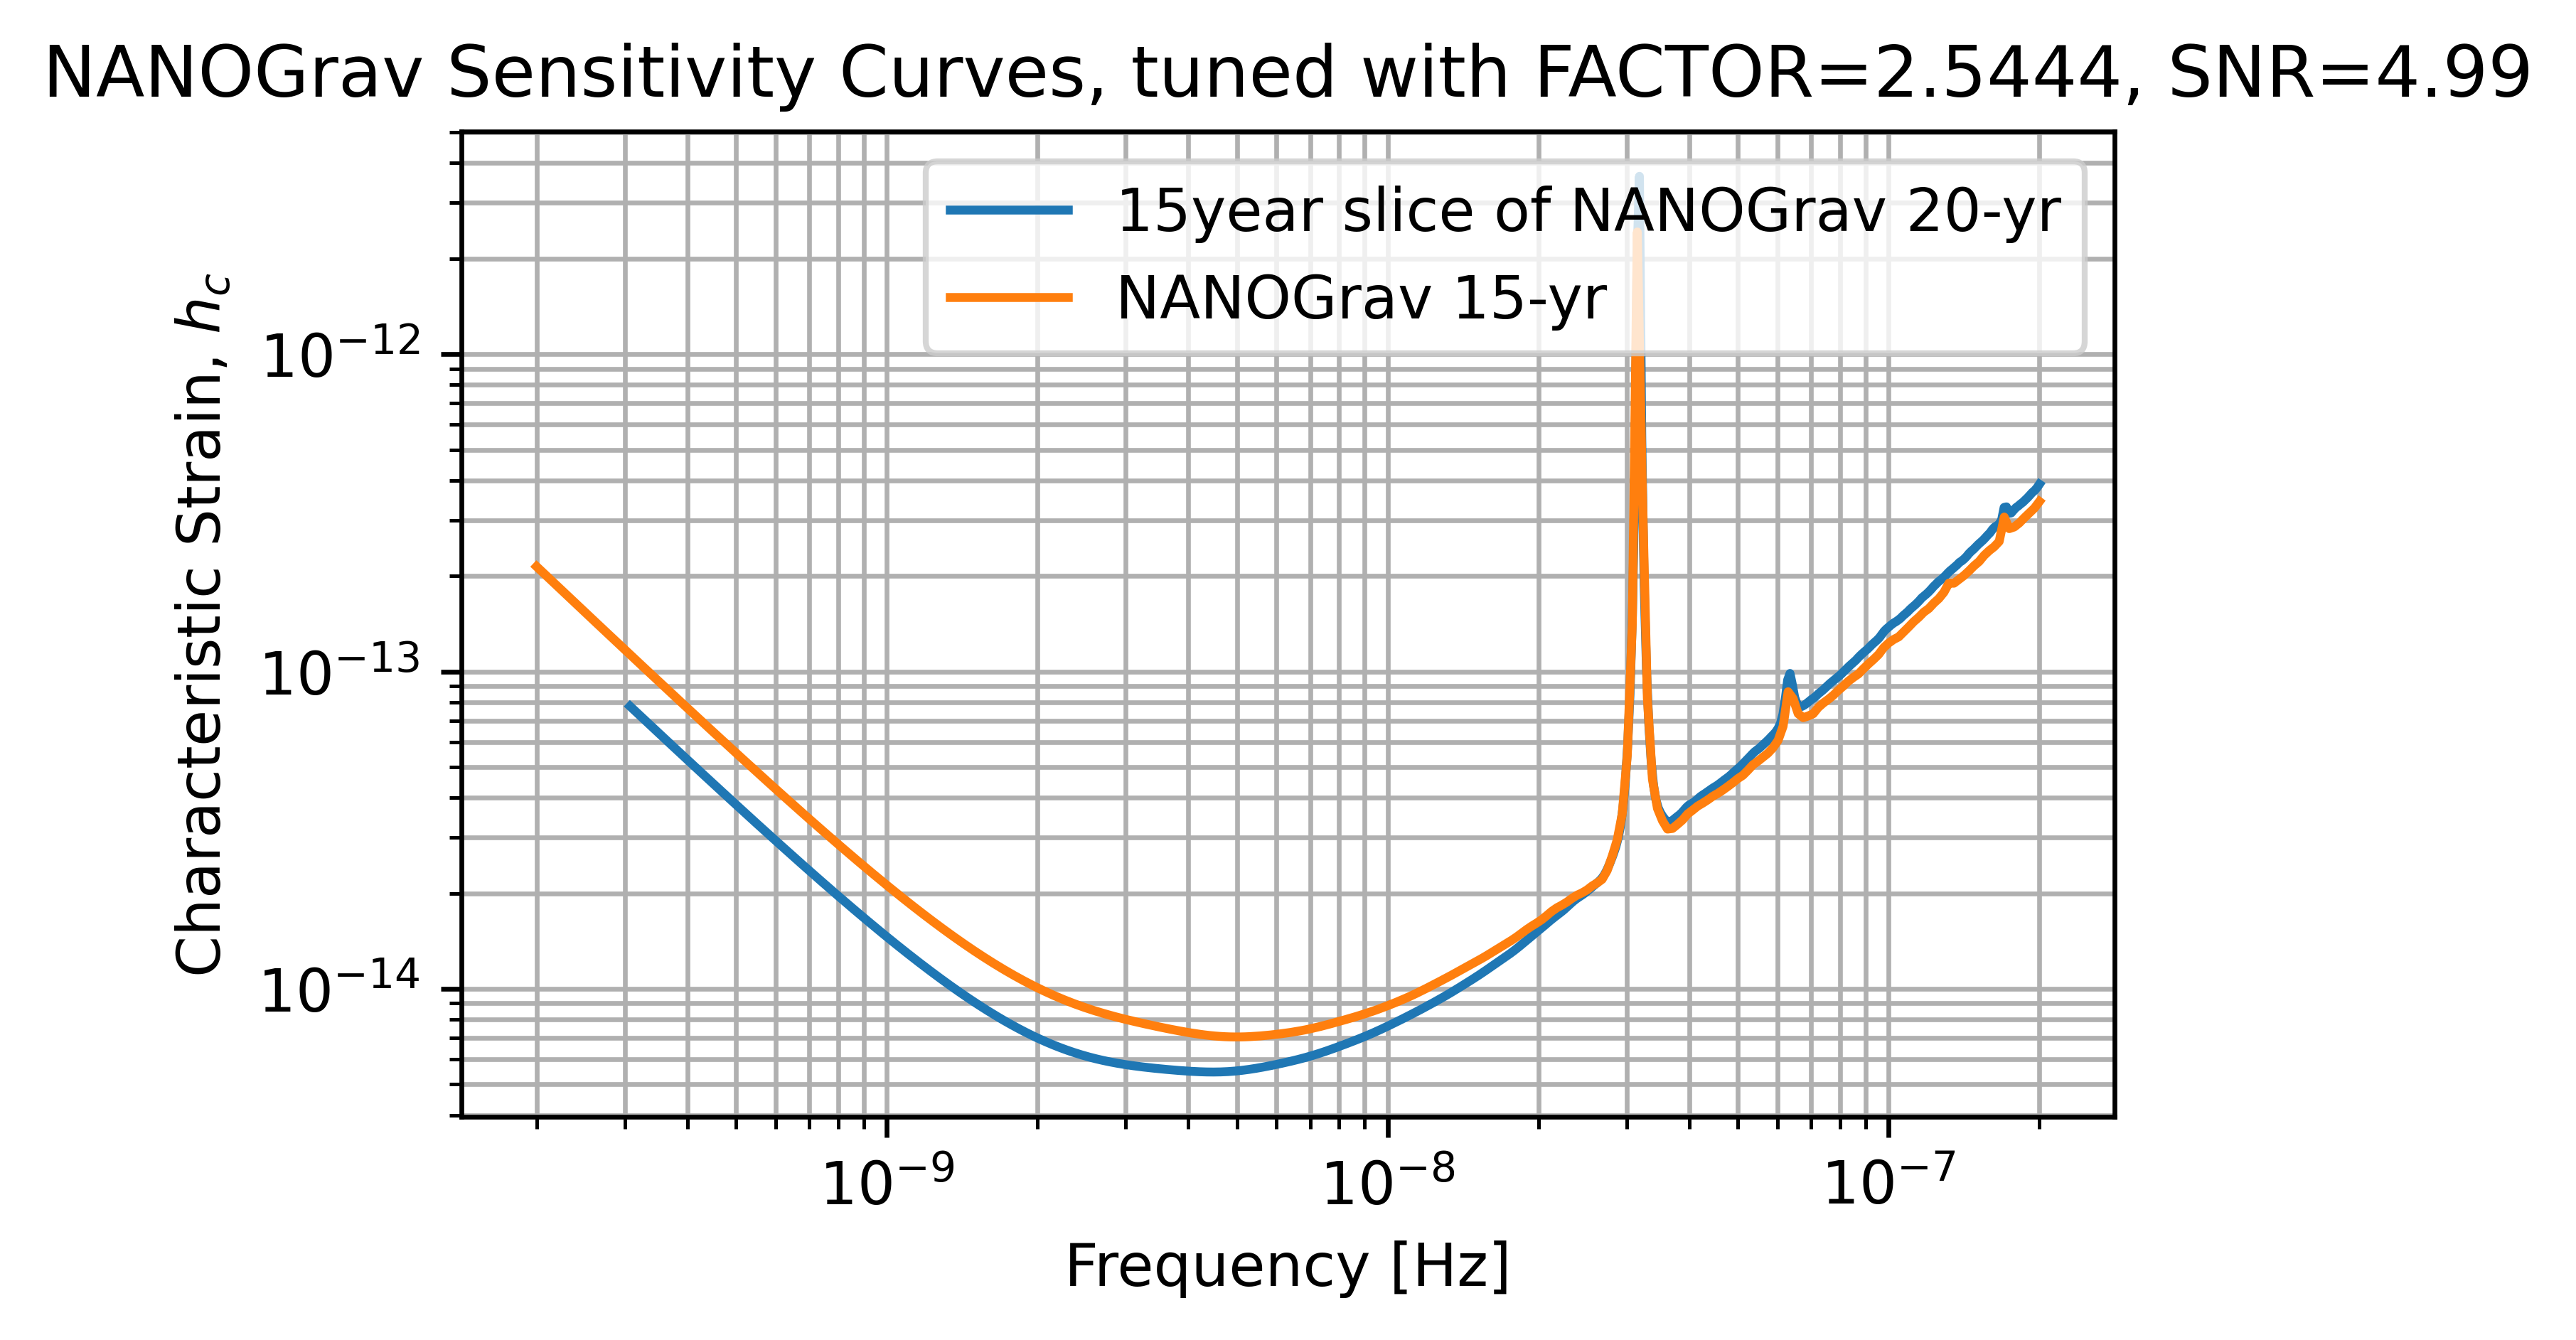

FACTOR =  2.570058083812998
PSR J2322+2057 completesliced_with_factor_SNR =  4.9792833718087


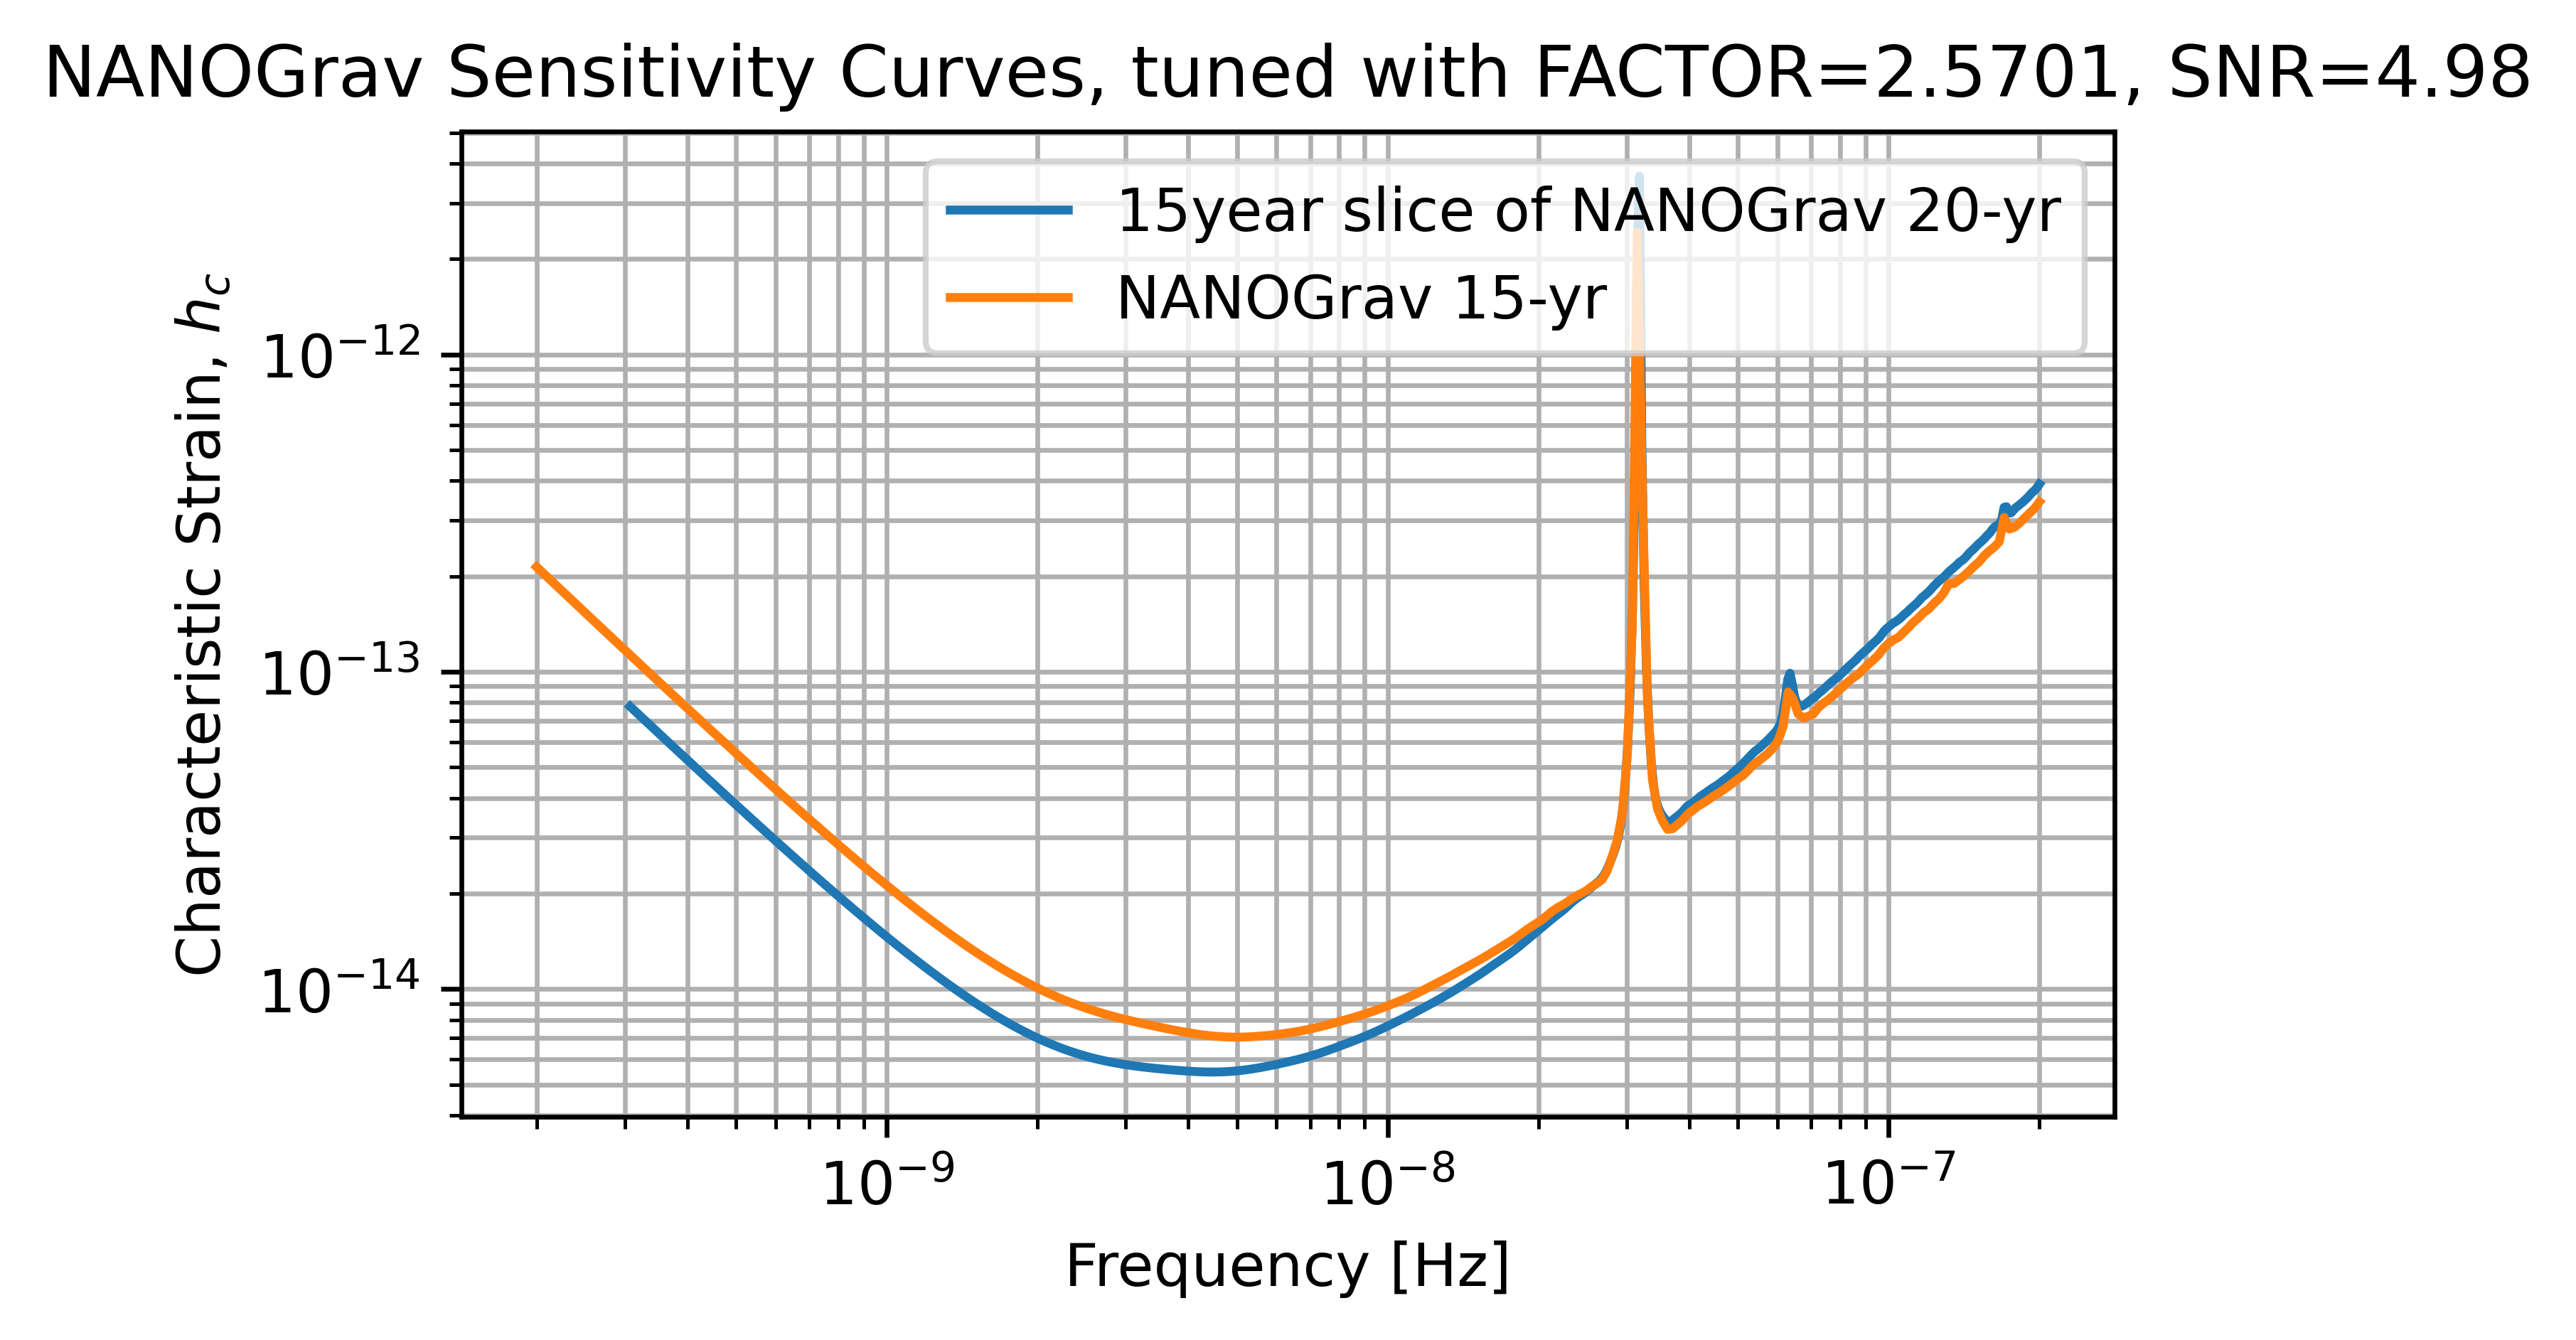

FACTOR =  5.140116167625996
PSR J2322+2057 completesliced_with_factor_SNR =  3.991488557796869


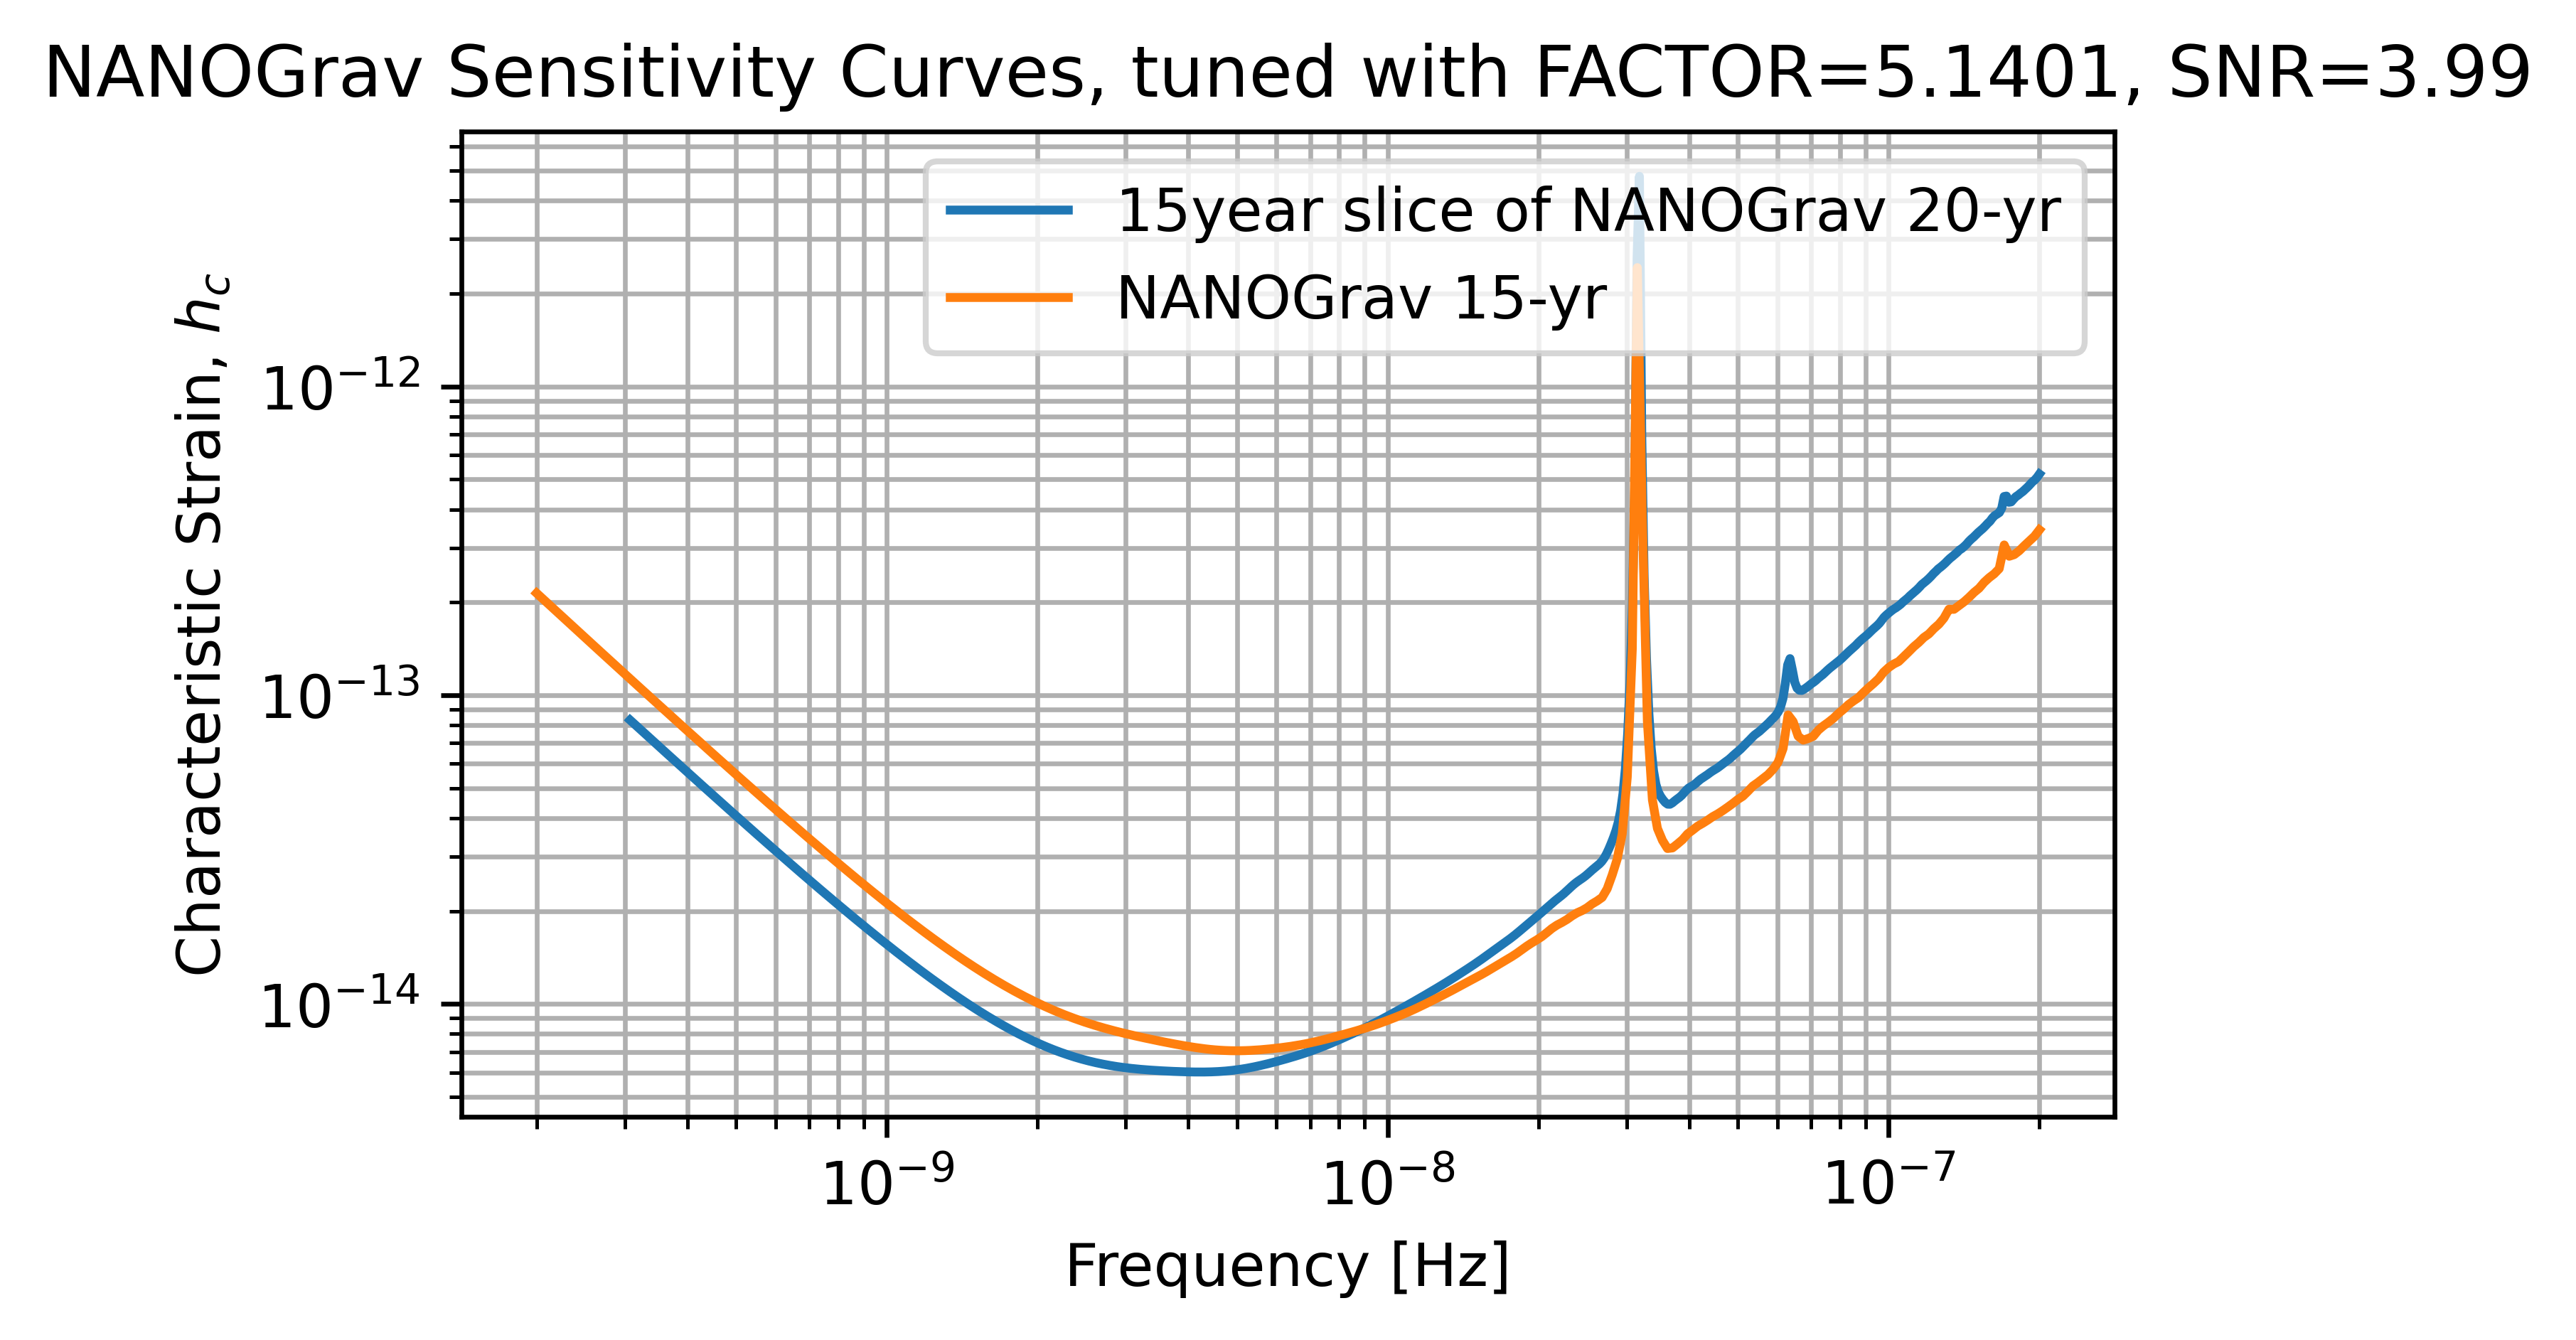

In [101]:
sliced_15yr_SNRS = []
for prefactor in [0.98,0.985,0.99,1,2]:
    FACTOR = prefactor*1.45*np.sqrt(np.pi)
    print("FACTOR = ", FACTOR)    
    A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
    psrs = []
    thin = 1
    for ePsr in epsrs_cut_NG15:
        nihans_corr = make_corr_our_tuning_with_all_wn(ePsr,nihans_noise,FACTOR=FACTOR)
        plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
        if ePsr.name in rn_psrs.keys():
            Amp, gam = rn_psrs[ePsr.name]
            plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

        nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                                toas=ePsr.toas[::thin])
        psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                        toaerrs=ePsr.toaerrs[::thin],
                        phi=ePsr.phi,theta=ePsr.theta,
                        N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
        psr.name = ePsr.name
        psrs.append(psr)
        del ePsr
    print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

    specs = []
    for p in psrs:
        sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
        _ = sp.NcalInv
        specs.append(sp)
        #print('\rPSR {0} complete'.format(p.name),end='',flush=True)

    ng20_sarah_sc_with_factor = hsen.GWBSensitivityCurve(specs)
    sliced_with_factor_SNR = ng20_sarah_sc_with_factor.SNR(S_h)
    sliced_15yr_SNRS.append(sliced_with_factor_SNR)
    print("sliced_with_factor_SNR = ", sliced_with_factor_SNR)

    plt.loglog(ng20_sarah_sc_with_factor.freqs,ng20_sarah_sc_with_factor.h_c,label='15year slice of NANOGrav 20-yr')
    plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Characteristic Strain, $h_c$')
    plt.title(
    'NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}, SNR={:.2f}'.format(
        FACTOR, sliced_with_factor_SNR
    )
)
    #plt.title('NANOGrav 20-15-year Data Set Sensitivity Curve, tuned with FACTOR={0}'.format(FACTOR))
    plt.grid(which='both')
    # plt.ylim(1e-15,9e-12)
    plt.legend()
    plt.show()

The last one is just to show that the sensitivity curve is being affected by the factor although it might not seem like it with the first three values of factor!

### So to conclude, if you use a factor of 2.544357502974868 on toaerror, and use the noise dict formed by the combination of 15year WN + (CHIME, VEGAS, extra pulsars) from real NG20, then you will get an SNR of 4.99 on the NG15 slice of the simulated NG20 dataset. 

FACTOR =  2.54
PSR J2322+2057 completesliced_with_factor_SNR =  4.996409156873098


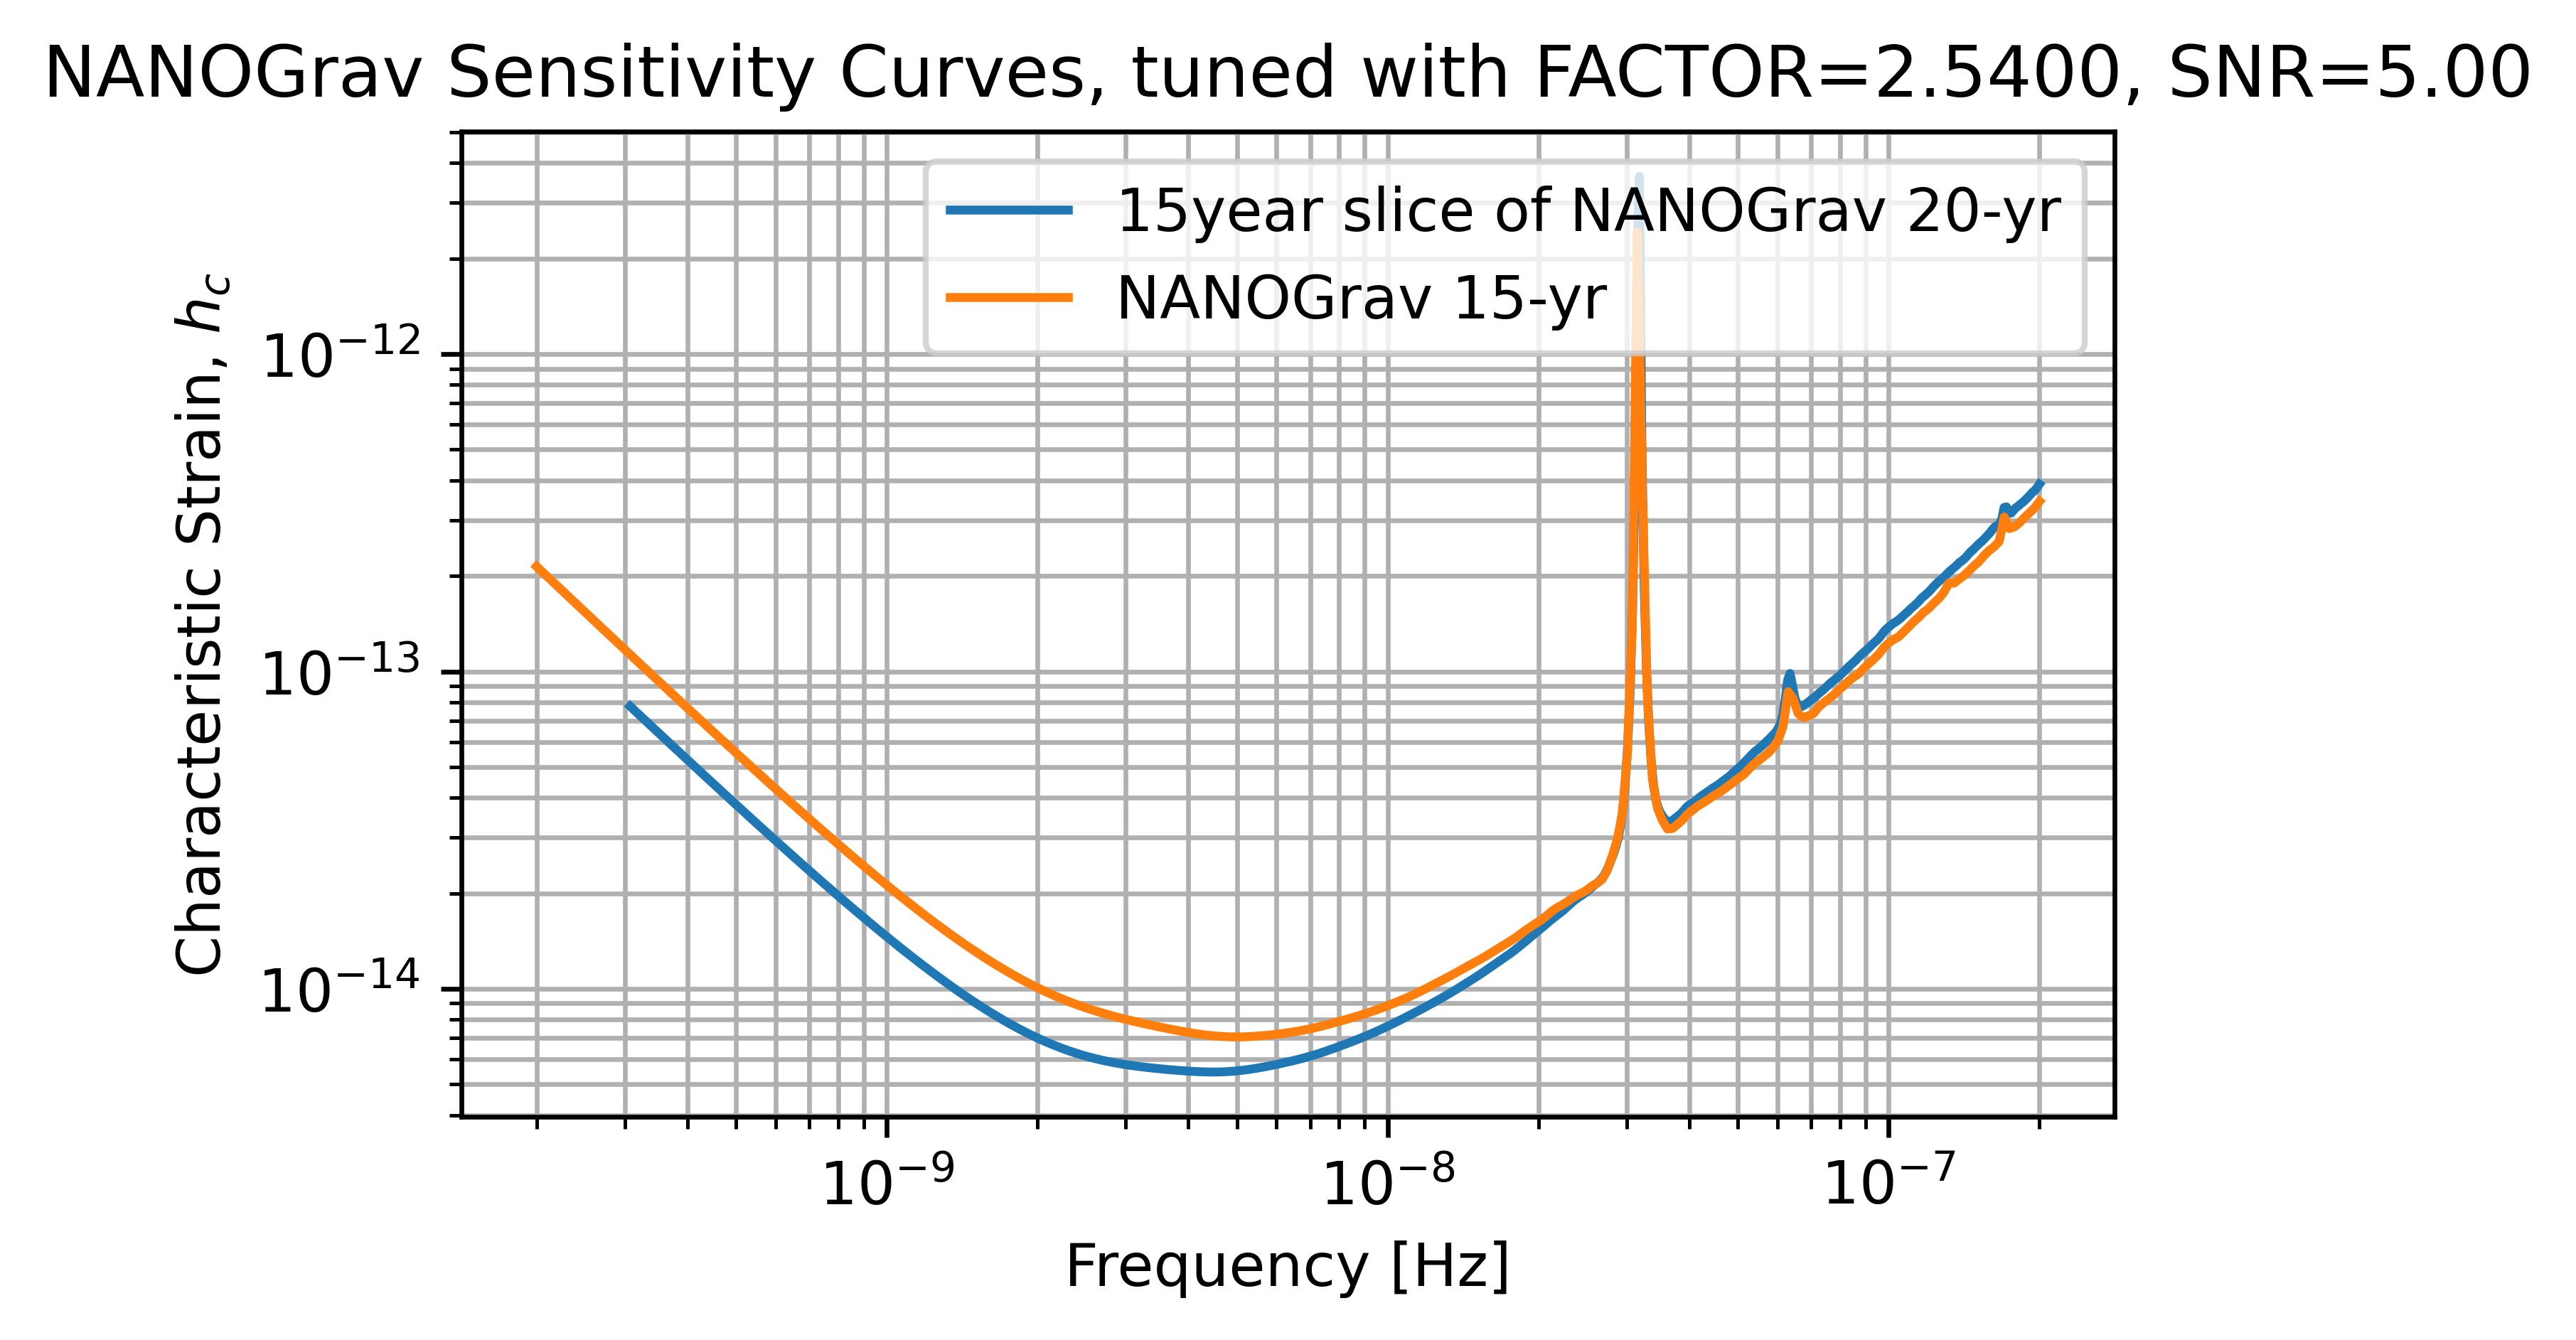

In [45]:
#FACTOR = prefactor*1.45*np.sqrt(np.pi)
sliced_15yr_SNRS = []
FACTOR  = 2.54
print("FACTOR = ", FACTOR)    
A_gwb, gamma_gwb = 6.4e-15, 3.2 # median values from detection paper
psrs = []
thin = 1
for ePsr in epsrs_cut_NG15:
    nihans_corr = make_corr_our_tuning_with_all_wn(ePsr,nihans_noise,FACTOR=FACTOR)
    plaw = hsen.red_noise_powerlaw(A=A_gwb, gamma=gamma_gwb, freqs=freqs)
    if ePsr.name in rn_psrs.keys():
        Amp, gam = rn_psrs[ePsr.name]
        plaw += hsen.red_noise_powerlaw(A=10**Amp, gamma=gam, freqs=freqs)

    nihans_corr += hsen.corr_from_psd(freqs=freqs, psd=plaw,
                            toas=ePsr.toas[::thin])
    psr = hsen.Pulsar(toas=ePsr.toas[::thin],
                    toaerrs=ePsr.toaerrs[::thin],
                    phi=ePsr.phi,theta=ePsr.theta,
                    N=nihans_corr, designmatrix=ePsr.Mmat[::thin,:])
    psr.name = ePsr.name
    psrs.append(psr)
    del ePsr
print('\rPSR {0} complete'.format(psr.name),end='',flush=True)

specs = []
for p in psrs:
    sp = hsen.Spectrum(p, freqs=freqs,amp_gw=None, gamma_gw=None)
    _ = sp.NcalInv
    specs.append(sp)
    #print('\rPSR {0} complete'.format(p.name),end='',flush=True)

ng20_sarah_sc_with_factor = hsen.GWBSensitivityCurve(specs)
sliced_with_factor_SNR = ng20_sarah_sc_with_factor.SNR(S_h)
sliced_15yr_SNRS.append(sliced_with_factor_SNR)
print("sliced_with_factor_SNR = ", sliced_with_factor_SNR)

plt.loglog(ng20_sarah_sc_with_factor.freqs,ng20_sarah_sc_with_factor.h_c,label='15year slice of NANOGrav 20-yr')
plt.loglog(ng15_sc_gwb.freqs,ng15_sc_gwb.h_c,label='NANOGrav 15-yr')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Characteristic Strain, $h_c$')
plt.title(
'NANOGrav Sensitivity Curves, tuned with FACTOR={:.4f}, SNR={:.2f}'.format(
    FACTOR, sliced_with_factor_SNR
)
)
#plt.title('NANOGrav 20-15-year Data Set Sensitivity Curve, tuned with FACTOR={0}'.format(FACTOR))
plt.grid(which='both')
# plt.ylim(1e-15,9e-12)
plt.legend()
plt.show()